# RAG Faithfulness: English versus Dutch Queries

**Course:** Transformers: Applications in Language and Communication (INFOMTALC)  
**Authors:** Chiel van Barneveld, Jasmijn Vennink, Kieran den Hollander, Wouter Heinis  
**University:** Utrecht University

---

## Research Question

> Does querying a monolingual English knowledge base in Dutch reduce the faithfulness and accuracy of a RAG system's answers, and if so, what error patterns emerge?

---

## Notebook Structure

| Section | Content |
|---------|---------|
| 1 | Environment setup |
| 2 | Knowledge base construction (Wikipedia) |
| 3 | Chunking & embedding |
| 4 | Question set (EN + NL) |
| 5 | RAG pipeline (retrieval + generation) |
| 5b | Running the pipeline on all questions |
| 6 | Faithfulness evaluation (RAGAS) |
| 7 | Results & error analysis |

### Reproducibility note

This notebook was developed on Google Colab (T4 GPU runtime). To reproduce the results:

1. Upload the file `voc_rag_questions_COMPLETE.xlsx` to the Colab session (used in Section 4).
2. The pipeline generates `rag_results_complete.xlsx` (Section 5b). We include this file alongside the submission so results can be verified without re-running the full pipeline.
3. Section 7 (RAGAS evaluation) requires an OpenAI API key (`OPENAI_API_KEY`) stored in Colab Secrets, since RAGAS uses GPT-4o-mini as a judge LLM.
4. Section 5 requires a Hugging Face token with access to `meta-llama/Llama-3.2-3B-Instruct`.

## 1. Environment Setup

We install all required libraries. Key dependencies:
- `sentence-transformers` — for the multilingual embedding model
- `faiss-cpu` — for fast similarity search over the chunk embeddings
- `transformers` + `accelerate` — for loading and running Llama 3.2 3B Instruct
- `wikipedia-api` — for fetching English Wikipedia articles
- `ragas` + `langchain` — for automated faithfulness evaluation
- `pandas`, `matplotlib`, `seaborn` — for data handling and visualisation

In [ ]:
# pip install all dependencies we might need
!pip install -q \
    transformers \
    sentence-transformers \
    faiss-cpu \
    wikipedia-api \
    datasets \
    accelerate \
    bitsandbytes \
    ragas \
    langchain \
    langchain-community \
    pandas \
    matplotlib \
    seaborn \
    tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0

In [ ]:
import os
import json
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wikipediaapi
import faiss
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## 2. Knowledge Base Construction

We construct a monolingual **English** knowledge base by pulling 27 articles from English Wikipedia. The articles cover the Dutch East India Company (VOC) and related topics, grouped into several thematic clusters:

- **VOC core:** The company itself and its governing board (Heeren XVII)
- **Key figures:** Jan Pieterszoon Coen, Cornelis de Houtman, Anthony van Diemen, Johan van Oldenbarnevelt
- **Trade & colonies:** Dutch East Indies, Formosa, Ceylon, Cape Colony, Batavia, the spice trade, New Amsterdam
- **Historical context:** Dutch Golden Age, Dutch Republic, Anglo-Dutch Wars, the WIC
- **Slavery & colonial violence:** History of slavery in the Netherlands, Elmina Castle, Suriname, the Banda Islands conquest, Pattimura, the Indonesian National Revolution

This topic was chosen because it has rich English Wikipedia coverage while being highly relevant for Dutch-language users, exactly the scenario where a Dutch speaker would plausibly query an English-only knowledge base.

We use the `wikipediaapi` library with a polite crawl delay of 0.3 seconds between requests.


In [ ]:
ARTICLES = [
    # VOC
    "Dutch East India Company",
    "Heeren XVII",

    # Key people
    "Jan Pieterszoon Coen",
    "Johan van Oldenbarnevelt",
    "Cornelis de Houtman",
    "Anthony van Diemen",

    # Trade routes & colonies
    "Dutch_Formosa",
    "Dutch_East_Indies",
    "Dutch_Ceylon",
    "Cape_Colony",
    "Batavia,_Dutch_East_Indies",
    "Spice_trade",
    "Dutch_colonization_of_the_Americas",

    # Context
    "Dutch_Golden_Age",
    "Dutch_Republic",
    "Anglo-Dutch_Wars",
    "Dutch_West_India_Company",

    # Slavery & the slave trade
    "History_of_slavery_in_the_Netherlands",
    "Elmina_Castle",
    "History_of_Suriname",
    "Dutch_Caribbean",
    "Slavery_in_South_Africa",

    # Colonial violence & resistance
    "Dutch_conquest_of_the_Banda_Islands",
    "Pattimura",
    "Indonesian_National_Revolution",
    "Dutch_Brazil",

    # Additional colony
    "New_Amsterdam",
]

print(f"Target articles: {len(ARTICLES)}")

Target articles: 27


In [ ]:
# Fetch Wiki articles
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='RAG-Faithfulness-Study/1.0 (master-research-project)'
)

raw_articles = {}
failed = []

for title in tqdm(ARTICLES, desc="Fetching articles"):
    page = wiki.page(title)
    if page.exists():
        raw_articles[title] = {
            'title': page.title,
            'text': page.text,
            'url': page.fullurl
        }
    else:
        failed.append(title)
    time.sleep(0.3)  # polite crawl delay

print(f"\nFetched: {len(raw_articles)} articles")
if failed:
    print(f"Not found (check spelling): {failed}")

Fetching articles: 100%|██████████| 27/27 [00:16<00:00,  1.60it/s]


Fetched: 27 articles


In [ ]:
# Quick sanity check
# Prints the first 300 chars of an article
sample = list(raw_articles.values())[0]
print(f"Title: {sample['title']}")
print(f"Length: {len(sample['text'])} chars")
print("\nPreview:")
print(sample['text'][:300])

Title: Dutch East India Company
Length: 49100 chars

Preview:
The United East India Company (Dutch: Vereenigde Oostindische Compagnie [vərˈeːnɪɣdə oːstˈɪndisə kɔmpɑˈɲi]; abbr. VOC [veː(j)oːˈseː]), commonly known as the Dutch East India Company, was a chartered trading company and one of the first joint-stock companies in the world. Established on 20 March 1602


## 3. Chunking & Embedding

### Chunking strategy
Each article is split into overlapping word-based chunks of approximately **200 words**, with an **overlap of 40 words** between consecutive chunks. The overlap ensures that information near chunk boundaries is not lost during retrieval. This produces a total of ~770 chunks across all 27 articles.

### Embedding model
We embed all chunks using **`intfloat/multilingual-e5-small`**, a multilingual sentence embedding model. This model was chosen because:

1. It supports both English and Dutch, which is essential for our cross-lingual setup: the same vector space must handle English chunks and Dutch queries.
2. It is lightweight enough to run efficiently on a Colab GPU.

The embeddings are stored in a **FAISS index** (flat L2 distance) for fast nearest-neighbour search at query time. Since our corpus is relatively small (~770 chunks), an exact search index is sufficient and no approximate methods are needed.


In [ ]:
# Chunking
# We can experiment with CHUNK_SIZE and OVERLAP to see if it affects retrieval
# quality

CHUNK_SIZE = 200    # words per chunk
OVERLAP    = 40     # word overlap between consecutive chunks

def chunk_text(text, chunk_size=CHUNK_SIZE, overlap=OVERLAP):
    """Split text into overlapping word-based chunks."""
    # Clean up whitespace
    text = re.sub(r'\n+', ' ', text).strip()
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(' '.join(words[start:end]))
        if end == len(words):
            break
        start += chunk_size - overlap
    return chunks


all_chunks = []  # list of dicts: {text, source_title, chunk_id}

for title, article in raw_articles.items():
    chunks = chunk_text(article['text'])
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            'text': chunk,
            'source': article['title'],
            'chunk_id': f"{title}_{i}"
        })

print(f"Total chunks: {len(all_chunks)}")
print(f"Average chunk length: {np.mean([len(c['text'].split()) for c in all_chunks]):.0f} words")

Total chunks: 675
Average chunk length: 197 words


In [ ]:
# Embedding model
EMBED_MODEL_NAME = 'intfloat/multilingual-e5-small'

print(f"Loading embedding model: {EMBED_MODEL_NAME}")
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print("Embedding model loaded.")

Loading embedding model: intfloat/multilingual-e5-small


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Embedding model loaded.


## 4. Question Set (EN + NL)

We designed a set of **80 parallel question pairs** — each question exists in both English and Dutch. The English versions were written first, then translated to Dutch and verified by native speakers. The questions are divided into three difficulty levels that test increasingly complex reasoning:

| Level | Count | Description | Example (EN) |
|-------|-------|-------------|--------------|
| **Level 1** | 33 | Simple factual retrieval — the answer is a single fact in one chunk | *"In what year was the VOC founded?"* |
| **Level 2** | 27 | Single-document reasoning — requires synthesising multiple sentences from one article | *"What were the main reasons for the VOC's financial decline?"* |
| **Level 3** | 20 | Cross-document reasoning — requires connecting information across multiple articles | *"How did the fall of Antwerp influence both the founding of the VOC and the cultural flourishing of Amsterdam's Golden Age?"* |

This three-level design lets us test where cross-lingual performance degrades. If Level 1 already fails in Dutch, the problem is at the retrieval stage (the embedding model cannot match the Dutch query to the English chunk). If Level 1 works but Level 2 degrades, retrieval is fine but generation struggles with cross-lingual reasoning. Level 3 is the hardest condition, where the model must do cross-lingual reasoning and multi-document synthesis simultaneously.

Each question comes with:
- A **gold-standard answer** (the factually correct answer)
- A **key facts checklist** (specific facts that must appear in a correct answer)
- The **source article(s)** where the answer can be found
- **Verbatim evidence** extracted from the raw Wikipedia text

The questions are loaded from the file `voc_rag_questions_COMPLETE.xlsx`.


In [ ]:
## 4. Question set (EN + NL)

import pandas as pd

# Load questions from Excel
df_q = pd.read_excel("/content/voc_rag_questions_COMPLETE.xlsx", sheet_name="VOC_RAG_Questions")

# Build question lists with metadata
questions_en = []
questions_nl = []

for _, row in df_q.iterrows():
    meta = {
        "id": row["ID"],
        "level": row["Level"],
        "gold_answer": row["Gold Answer (EN)"],
        "key_facts": row["Key Facts Checklist"],
        "source_articles": row["Source Article(s)"]
    }
    questions_en.append({"question": row["Question (EN)"], **meta})
    questions_nl.append({"question": row["Question (NL)"], **meta})

print(f"Loaded {len(questions_en)} EN + {len(questions_nl)} NL questions")

Loaded 80 EN + 80 NL questions


## 5. RAG Pipeline (Retrieval + Generation)

The RAG pipeline has three stages: indexing, retrieval, and generation.

### 5.1 Indexing
All chunk embeddings (from Section 3) are added to a FAISS flat-L2 index, enabling exact nearest-neighbour search.

### 5.2 Retrieval
Given a query (in English or Dutch), we:
1. Embed the query using the same multilingual-e5-small model.
2. Search the FAISS index for the **top-3** most similar chunks.

Because both the chunks and the queries are embedded in the same multilingual vector space, a Dutch query can in principle retrieve English chunks — this is the cross-lingual retrieval that makes our experiment possible.

### 5.3 Generation
We use **Llama 3.2 3B Instruct** (`meta-llama/Llama-3.2-3B-Instruct`) as the generator. This is a small, locally-runnable model, chosen to avoid API costs and rate limits. The model is loaded in full precision with `device_map="auto"`.

The prompt instructs the model to:
- Answer **only** based on the provided context (to encourage faithfulness)
- Answer **in the same language as the question** (so English questions get English answers, Dutch questions get Dutch answers)

Generation uses greedy decoding (`do_sample=False`) with a maximum of 200 new tokens, ensuring reproducible outputs.

> **Note:** A Hugging Face token with access to the Llama 3.2 model is required. Store it as `HF_TOKEN` in Colab Secrets.


In [ ]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [ ]:
# 1. Build FAISS index

# Extract text from chunks
chunk_texts = [c["text"] for c in all_chunks]

# Embed all chunks
chunk_embs = embed_model.encode(chunk_texts, convert_to_numpy=True)

# Create FAISS index (L2 similarity)
index = faiss.IndexFlatL2(chunk_embs.shape[1])

# Add embeddings to index
index.add(chunk_embs)


# 2. Retrieval function

def retrieve(q, k=5):
    # Embed the query
    q_emb = embed_model.encode([q], convert_to_numpy=True)
    # Search top‑k similar chunks
    _, I = index.search(q_emb, k)
    # Return the actual chunk dicts
    return [all_chunks[i] for i in I[0]]


# 3. Load Llama 3.2 3B Instruct

GEN_MODEL = "meta-llama/Llama-3.2-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL)
model = AutoModelForCausalLM.from_pretrained(
    GEN_MODEL,
    device_map="auto"
)

pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)


# 4. RAG answer function


def rag_answer(q, k=3):
    # Retrieve top-k chunks
    retrieved = retrieve(q, k)
    ctx = "\n\n".join(c["text"] for c in retrieved)

    # Build prompt
    prompt = (
        "Answer the question based ONLY on the context below. "
        "Answer in the same language as the question.\n\n"
        f"Context:\n{ctx}\n\n"
        f"Question: {q}\n"
        "Answer:"
    )

    # Generate answer
    out = pipe(prompt, max_new_tokens=200, do_sample=False)
    # Strip prompt from output, keep only the answer
    answer = out[0]["generated_text"].split("Answer:")[-1].strip()

    return answer, retrieved


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

## 5b. Run Pipeline on All Questions

We run the full RAG pipeline (retrieve + generate) for all 80 questions in both languages, producing **160 question-answer pairs** in total (80 EN + 80 NL).

For each question, we store:
- The generated answer
- The sources of the retrieved chunks (to evaluate retrieval quality)
- The full text of the retrieved chunks (needed for RAGAS faithfulness scoring)

The results are saved as `rag_results_complete.xlsx` with separate sheets per difficulty level. This file is included with the submission so the evaluation in Section 7 can be run independently.

> **Runtime:** On a T4 GPU, this step takes approximately 15–20 minutes for all 160 queries.


In [ ]:
## 5b. Run pipeline on all questions

results = []

for lang, qlist in [("EN", questions_en), ("NL", questions_nl)]:
    for q in tqdm(qlist, desc=f"Running {lang} queries"):
        # One call does both retrieval and generation
        answer, retrieved = rag_answer(q["question"], k=3)

        results.append({
            "id": q["id"],
            "level": q["level"],
            "language": lang,
            "question": q["question"],
            "gold_answer": q["gold_answer"],
            "key_facts": q["key_facts"],
            "generated_answer": answer,
            "retrieved_sources": [c["source"] for c in retrieved],
            "retrieved_texts": [c["text"] for c in retrieved]
        })

df_results = pd.DataFrame(results)
df_results.to_csv("rag_results.csv", index=False)
print(f"Total results: {len(df_results)}")

Running EN queries:   0%|          | 0/80 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Running EN queries:   1%|▏         | 1/80 [00:04<05:19,  4.05s/it]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `m

Total results: 160


### Output formatting

The code below merges the English and Dutch results side-by-side per question and writes them to a formatted Excel file (`rag_results_complete.xlsx`). English columns are highlighted in blue, Dutch columns in orange, for easy visual comparison.


In [ ]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ── 1. Splits EN en NL en merge op ID ────────────────────────────────────────
df_en = df_results[df_results["language"] == "EN"].copy()
df_nl = df_results[df_results["language"] == "NL"].copy()

df_merged = df_en.merge(
    df_nl[["id", "question", "generated_answer", "retrieved_sources", "retrieved_texts"]],
    on="id",
    suffixes=("_EN", "_NL")
)

# ── 2. Merge met vragenset voor source_articles ───────────────────────────────
df_q = pd.read_excel("/content/voc_rag_questions_COMPLETE.xlsx", sheet_name="VOC_RAG_Questions")
df_merged = df_merged.merge(df_q[["ID", "Source Article(s)"]], left_on="id", right_on="ID", how="left").drop(columns=["ID", "language"])

# ── 3. Herorden kolommen ──────────────────────────────────────────────────────
df_merged = df_merged[[
    "id", "level",
    "question_EN", "question_NL",
    "gold_answer", "key_facts",
    "generated_answer_EN", "generated_answer_NL",
    "Source Article(s)",
    "retrieved_sources_EN", "retrieved_sources_NL",
    "retrieved_texts_EN", "retrieved_texts_NL"
]]

df_merged.columns = [
    "ID", "Level",
    "Question (EN)", "Question (NL)",
    "Gold Answer", "Key Facts",
    "Generated Answer (EN)", "Generated Answer (NL)",
    "Expected Sources",
    "Retrieved Sources (EN)", "Retrieved Sources (NL)",
    "Retrieved Texts (EN)", "Retrieved Texts (NL)"
]

print(f"Aantal rijen: {len(df_merged)}")  # moet 80 zijn

# ── 4. Schrijf naar Excel ─────────────────────────────────────────────────────
output_path = "rag_results_complete.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_merged.to_excel(writer, sheet_name="All Results", index=False)

    # Per level een apart tabblad
    for level in df_merged["Level"].unique():
        df_merged[df_merged["Level"] == level].to_excel(
            writer, sheet_name=level.replace(" ", ""), index=False
        )

# ── 5. Opmaak ─────────────────────────────────────────────────────────────────
wb = load_workbook(output_path)

header_fill = PatternFill("solid", start_color="2F4F7F", end_color="2F4F7F")
en_fill     = PatternFill("solid", start_color="DDEEFF", end_color="DDEEFF")
nl_fill     = PatternFill("solid", start_color="FFEEDD", end_color="FFEEDD")
header_font = Font(name="Arial", bold=True, color="FFFFFF", size=11)
cell_font   = Font(name="Arial", size=10)
thin_border = Border(
    left=Side(style="thin"), right=Side(style="thin"),
    top=Side(style="thin"),  bottom=Side(style="thin")
)

col_widths = {
    "ID": 8, "Level": 10,
    "Question (EN)": 40, "Question (NL)": 40,
    "Gold Answer": 45, "Key Facts": 35,
    "Generated Answer (EN)": 50, "Generated Answer (NL)": 50,
    "Expected Sources": 30,
    "Retrieved Sources (EN)": 30, "Retrieved Sources (NL)": 30,
    "Retrieved Texts (EN)": 55, "Retrieved Texts (NL)": 55
}

# EN-kolommen (blauw) en NL-kolommen (oranje) per cel inkleuren
en_cols = {"Question (EN)", "Generated Answer (EN)", "Retrieved Sources (EN)", "Retrieved Texts (EN)"}
nl_cols = {"Question (NL)", "Generated Answer (NL)", "Retrieved Sources (NL)", "Retrieved Texts (NL)"}

for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]

    # Bepaal welke kolomindex EN of NL is
    headers = [ws.cell(1, c).value for c in range(1, ws.max_column + 1)]

    for col_idx, header in enumerate(headers, start=1):
        # Kolombreedtes
        ws.column_dimensions[get_column_letter(col_idx)].width = col_widths.get(header, 20)

        # Header opmaak
        hcell = ws.cell(1, col_idx)
        hcell.fill = header_fill
        hcell.font = header_font
        hcell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

        # Datacellen inkleuren per kolom
        if header in en_cols:
            bg = en_fill
        elif header in nl_cols:
            bg = nl_fill
        else:
            bg = PatternFill("solid", start_color="F5F5F5", end_color="F5F5F5")

        for row_idx in range(2, ws.max_row + 1):
            cell = ws.cell(row_idx, col_idx)
            cell.font      = cell_font
            cell.fill      = bg
            cell.border    = thin_border
            cell.alignment = Alignment(wrap_text=True, vertical="top")

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

wb.save(output_path)
print(f"✅ Opgeslagen als: {output_path}")

Aantal rijen: 80
✅ Opgeslagen als: rag_results_complete.xlsx


## 6. Evaluation & Results

In this section we evaluate the RAG pipeline outputs and analyse the results. All evaluation runs on the pre-generated results file `rag_results_complete.xlsx`, so this section can be reproduced independently without re-running the pipeline (Sections 2–5b).

We measure two aspects of performance:

1. **Faithfulness** (Section 6.1) — does the generated answer stay within what the retrieved context actually says, or does the model hallucinate?
2. **Retrieval quality** (Section 6.2) — did the pipeline retrieve the right passages in the first place?

Both are evaluated separately for the English and Dutch conditions, broken down by difficulty level, to reveal where the cross-lingual penalty occurs.

### Evaluation framework: RAGAS

We use **RAGAS** (Retrieval-Augmented Generation Assessment) for automated evaluation. RAGAS uses an LLM-as-judge approach: we use **GPT-4o-mini** (temperature 0) as the judge model via the OpenAI API.

> **Note:** An OpenAI API key is required. Store it as `OPENAI_API_KEY` in Colab Secrets.


In [ ]:
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, context_precision, context_recall
from ragas.run_config import RunConfig
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from google.colab import userdata

# ── API key ───────────────────────────────────────────────────
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# ── Judge LLM ─────────────────────────────────────────────────
judge_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini", temperature=0))
faithfulness.llm      = judge_llm
context_precision.llm = judge_llm
context_recall.llm    = judge_llm

# ── Run config (timeouts & retries) ──────────────────────────
config = RunConfig(timeout=120, max_retries=5, max_wait=180, max_workers=2)

# ── Load results ──────────────────────────────────────────────
df = pd.read_excel('rag_results_complete.xlsx', sheet_name='All Results')
df.fillna("Geen data", inplace=True)

def parse_list_col(val):
    """Parse a stringified Python list into an actual list."""
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else [str(result)]
    except Exception:
        return [str(val)]

df['Retrieved Texts (EN)'] = df['Retrieved Texts (EN)'].apply(parse_list_col)
df['Retrieved Texts (NL)'] = df['Retrieved Texts (NL)'].apply(parse_list_col)

print(f"Loaded {len(df)} question pairs from rag_results_complete.xlsx")
print(f"Levels: {df['Level'].value_counts().sort_index().to_dict()}")

Loaded 80 question pairs from rag_results_complete.xlsx
Levels: {'Level 1': 33, 'Level 2': 27, 'Level 3': 20}


### 6.1 Faithfulness

The RAGAS `faithfulness` metric measures whether the claims in a generated answer are supported by the retrieved context. It works by:

1. Decomposing the generated answer into individual claims.
2. For each claim, checking whether it can be inferred from the retrieved context.
3. Computing a score between 0 and 1 (1.0 = all claims are grounded in context).

We evaluate English and Dutch answers separately.

In [ ]:
# ── Build RAGAS datasets ──────────────────────────────────────
ds_en = Dataset.from_dict({
    'question': df['Question (EN)'].tolist(),
    'answer':   df['Generated Answer (EN)'].tolist(),
    'contexts': df['Retrieved Texts (EN)'].tolist(),
})

ds_nl = Dataset.from_dict({
    'question': df['Question (NL)'].tolist(),
    'answer':   df['Generated Answer (NL)'].tolist(),
    'contexts': df['Retrieved Texts (NL)'].tolist(),
})

# ── Evaluate faithfulness ─────────────────────────────────────
print(f"Evaluating faithfulness — English ({len(ds_en)} questions)...")
result_en = evaluate(ds_en, metrics=[faithfulness], run_config=config, raise_exceptions=False)
df_faith_en = result_en.to_pandas()
df_faith_en['Language'] = 'English'
df_faith_en['Level']    = df['Level'].tolist()
print(f"  ✓ Mean faithfulness EN: {df_faith_en['faithfulness'].mean():.3f}")

print(f"\nEvaluating faithfulness — Dutch ({len(ds_nl)} questions)...")
result_nl = evaluate(ds_nl, metrics=[faithfulness], run_config=config, raise_exceptions=False)
df_faith_nl = result_nl.to_pandas()
df_faith_nl['Language'] = 'Dutch'
df_faith_nl['Level']    = df['Level'].tolist()
print(f"  ✓ Mean faithfulness NL: {df_faith_nl['faithfulness'].mean():.3f}")

# ── Combine and save ──────────────────────────────────────────
df_faith = pd.concat([df_faith_en, df_faith_nl], ignore_index=True)
df_faith.to_csv("ragas_faithfulness_scores.csv", index=False)
print("\nScores saved → ragas_faithfulness_scores.csv")

Evaluating faithfulness — English (80 questions)...


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[33]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[34]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[3]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[4]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[38]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[5]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[40]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[41]: TimeoutError()


  ✓ Mean faithfulness EN: 0.843

Evaluating faithfulness — Dutch (80 questions)...


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

  ✓ Mean faithfulness NL: 0.658

Scores saved → ragas_faithfulness_scores.csv


── Faithfulness per level ──


,Language,Level,faithfulness
0,Dutch,Level 1,0.701
1,Dutch,Level 2,0.728
2,Dutch,Level 3,0.493
3,English,Level 1,0.901
4,English,Level 2,0.860
5,English,Level 3,0.733



── Faithfulness overall ──


,Language,faithfulness
0,Dutch,0.658
1,English,0.843


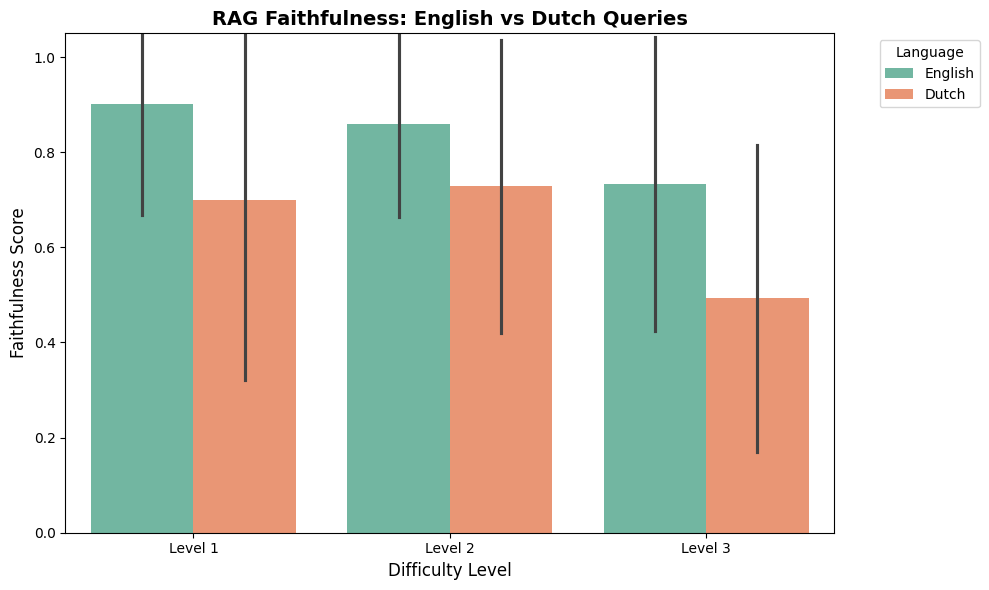

In [ ]:
# ── Summary tables ────────────────────────────────────────────
avg_by_level = df_faith.groupby(['Language', 'Level'])[['faithfulness']].mean().round(3).reset_index()
avg_overall  = df_faith.groupby('Language')[['faithfulness']].mean().round(3).reset_index()

print("── Faithfulness per level ──")
display(avg_by_level)
print("\n── Faithfulness overall ──")
display(avg_overall)

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_faith,
    x='Level',
    y='faithfulness',
    hue='Language',
    order=['Level 1', 'Level 2', 'Level 3'],
    palette='Set2',
    errorbar='sd',
)
plt.title('RAG Faithfulness: English vs Dutch Queries', fontsize=14, fontweight='bold')
plt.ylabel('Faithfulness Score', fontsize=12)
plt.xlabel('Difficulty Level', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Language', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("faithfulness_per_level_language.png", dpi=150)
plt.show()

### 6.2 Retrieval Quality (Context Precision, Recall, F1)

In addition to faithfulness (which measures generation quality), we evaluate **retrieval quality** to disentangle retrieval failures from generation failures:

- **Context Precision:** Of the retrieved chunks, how many are relevant? (higher = less noise)
- **Context Recall:** Of the relevant chunks, how many were retrieved? (higher = fewer misses)
- **Context F1:** Harmonic mean of precision and recall.

These metrics require a ground-truth answer (Gold Answer). The judge LLM uses this gold answer to assess whether each retrieved chunk contains information relevant to answering the question correctly — this is an LLM-based relevance judgement, not a hard source-name comparison.



In [ ]:
# ── Build RAGAS datasets (with ground_truth for retrieval metrics) ─
ds_en_ret = Dataset.from_dict({
    'question':     df['Question (EN)'].tolist(),
    'answer':       df['Generated Answer (EN)'].tolist(),
    'contexts':     df['Retrieved Texts (EN)'].tolist(),
    'ground_truth': df['Gold Answer'].tolist(),
})

ds_nl_ret = Dataset.from_dict({
    'question':     df['Question (NL)'].tolist(),
    'answer':       df['Generated Answer (NL)'].tolist(),
    'contexts':     df['Retrieved Texts (NL)'].tolist(),
    'ground_truth': df['Gold Answer'].tolist(),
})

# ── Evaluate retrieval ────────────────────────────────────────
print(f"Evaluating retrieval — English ({len(ds_en_ret)} questions)...")
result_en_ret = evaluate(ds_en_ret, metrics=[context_precision, context_recall], run_config=config, raise_exceptions=False)
df_ret_en = result_en_ret.to_pandas()
df_ret_en['Language'] = 'English'
df_ret_en['Level']    = df['Level'].tolist()
print(f"  ✓ Precision EN: {df_ret_en['context_precision'].mean():.3f} | Recall EN: {df_ret_en['context_recall'].mean():.3f}")

print(f"\nEvaluating retrieval — Dutch ({len(ds_nl_ret)} questions)...")
result_nl_ret = evaluate(ds_nl_ret, metrics=[context_precision, context_recall], run_config=config, raise_exceptions=False)
df_ret_nl = result_nl_ret.to_pandas()
df_ret_nl['Language'] = 'Dutch'
df_ret_nl['Level']    = df['Level'].tolist()
print(f"  ✓ Precision NL: {df_ret_nl['context_precision'].mean():.3f} | Recall NL: {df_ret_nl['context_recall'].mean():.3f}")

# ── Compute F1 and combine ────────────────────────────────────
def compute_f1(row):
    p, r = row['context_precision'], row['context_recall']
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

df_ret = pd.concat([df_ret_en, df_ret_nl], ignore_index=True)
df_ret['context_f1'] = df_ret.apply(compute_f1, axis=1)
df_ret.to_csv("ragas_retrieval_scores.csv", index=False)
print("\nScores saved → ragas_retrieval_scores.csv")

Evaluating retrieval — English (80 questions)...


Evaluating:   0%|          | 0/160 [00:00<?, ?it/s]

  ✓ Precision EN: 0.821 | Recall EN: 0.642

Evaluating retrieval — Dutch (80 questions)...


Evaluating:   0%|          | 0/160 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[30]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[100]: TimeoutError()


  ✓ Precision NL: 0.597 | Recall NL: 0.548

Scores saved → ragas_retrieval_scores.csv


── Retrieval per level ──


,Language,Level,Precision,Recall,F1
0,Dutch,Level 1,0.607,0.712,0.574
1,Dutch,Level 2,0.620,0.565,0.493
2,Dutch,Level 3,0.548,0.254,0.264
3,English,Level 1,0.785,0.803,0.763
4,English,Level 2,0.852,0.623,0.658
5,English,Level 3,0.837,0.400,0.480



── Retrieval overall ──


,Language,Precision,Recall,F1
0,Dutch,0.597,0.548,0.469
1,English,0.821,0.642,0.657


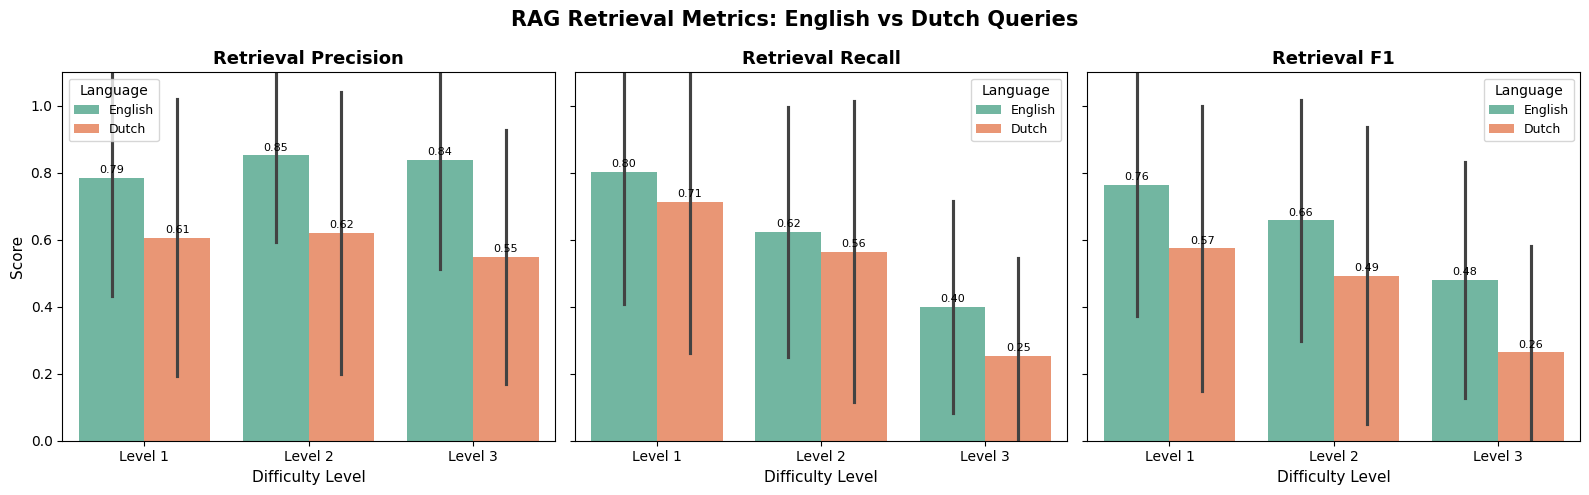

In [ ]:
# ── Summary tables ────────────────────────────────────────────
summary_level = (
    df_ret.groupby(['Language', 'Level'])[['context_precision', 'context_recall', 'context_f1']]
    .mean().round(3).reset_index()
    .rename(columns={'context_precision': 'Precision', 'context_recall': 'Recall', 'context_f1': 'F1'})
)
summary_overall = (
    df_ret.groupby('Language')[['context_precision', 'context_recall', 'context_f1']]
    .mean().round(3).reset_index()
    .rename(columns={'context_precision': 'Precision', 'context_recall': 'Recall', 'context_f1': 'F1'})
)

print("── Retrieval per level ──")
display(summary_level)
print("\n── Retrieval overall ──")
display(summary_overall)

# ── Plot ──────────────────────────────────────────────────────
metrics_info = [
    ('context_precision', 'Retrieval Precision'),
    ('context_recall',    'Retrieval Recall'),
    ('context_f1',        'Retrieval F1'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('RAG Retrieval Metrics: English vs Dutch Queries', fontsize=15, fontweight='bold')

for ax, (col, title) in zip(axes, metrics_info):
    sns.barplot(
        data=df_ret, x='Level', y=col, hue='Language',
        order=['Level 1', 'Level 2', 'Level 3'],
        palette='Set2', errorbar='sd', ax=ax,
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Difficulty Level', fontsize=11)
    ax.set_ylabel('Score' if ax == axes[0] else '', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.legend(title='Language', fontsize=9)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig("retrieval_metrics_per_level.png", dpi=150)
plt.show()

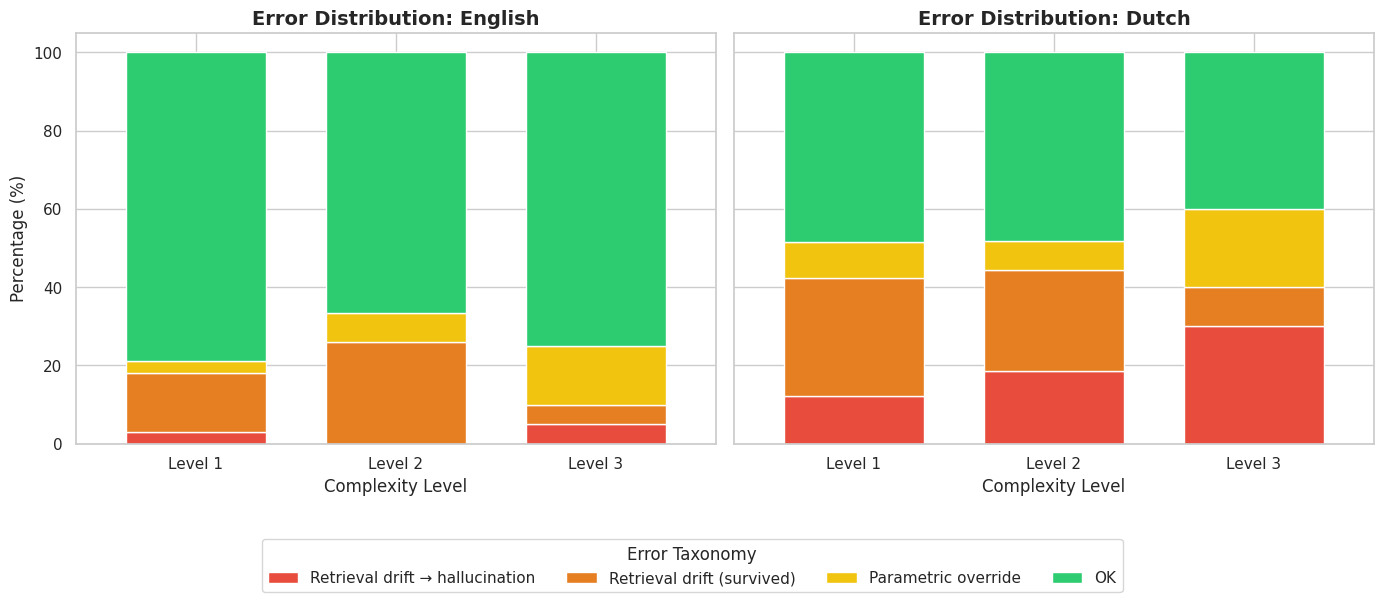

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#data loading
df_r = pd.read_csv('ragas_retrieval_scores.csv')
df_f = pd.read_csv('ragas_faithfulness_scores.csv')

PREC_THRESH  = 0.5
FAITH_THRESH = 0.5
LEVELS       = ['Level 1', 'Level 2', 'Level 3']
LANGUAGES    = ['English', 'Dutch']
ERROR_ORDER  = [
    'Retrieval drift → hallucination',
    'Retrieval drift (survived)',
    'Parametric override',
    'OK',
]
#colors
COLORS = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'] # Red, Orange, Yellow, Green

def classify_error(row):
    bad_ret   = row['context_precision'] < PREC_THRESH
    bad_faith = row['faithfulness']      < FAITH_THRESH
    if   bad_ret and     bad_faith: return 'Retrieval drift → hallucination'
    elif bad_ret and not bad_faith: return 'Retrieval drift (survived)'
    elif not bad_ret and bad_faith: return 'Parametric override'
    else:                           return 'OK'

frames = []
for lang in LANGUAGES:
    r = df_r[df_r['Language'] == lang].reset_index(drop=True)
    f = df_f[df_f['Language'] == lang].reset_index(drop=True)
    merged = r.copy()
    merged['faithfulness'] = f['faithfulness']
    merged['error_type']   = merged.apply(classify_error, axis=1)
    frames.append(merged)

df_all = pd.concat(frames, ignore_index=True)

#plot


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, lang in enumerate(LANGUAGES):

    plot_data = df_all[df_all['Language'] == lang]


    pivot_df = (
        plot_data.groupby(['Level', 'error_type'])
        .size()
        .unstack(fill_value=0)
        .reindex(index=LEVELS, columns=ERROR_ORDER, fill_value=0)
    )


    pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100


    pivot_pct.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=COLORS,
        width=0.7,
        edgecolor='white'
    )

    axes[i].set_title(f'Error Distribution: {lang}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Complexity Level')
    axes[i].set_ylabel('Percentage (%)' if i == 0 else '')
    axes[i].set_xticklabels(LEVELS, rotation=0)
    axes[i].get_legend().remove()


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05),
          ncol=4, title="Error Taxonomy", frameon=True)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig('error_taxonomy_plot.png', dpi=300)
plt.show()

In [ ]:
import pandas as pd

df_r = pd.read_csv('ragas_retrieval_scores.csv')
df_f = pd.read_csv('ragas_faithfulness_scores.csv')

PREC_THRESH  = 0.5
FAITH_THRESH = 0.5
LEVELS       = ['Level 1', 'Level 2', 'Level 3']
LANGUAGES    = ['English', 'Dutch']
ERROR_ORDER  = [
    'Retrieval drift → hallucination',
    'Retrieval drift (survived)',
    'Parametric override',
    'OK',
]

def classify_error(row):
    bad_ret   = row['context_precision'] < PREC_THRESH
    bad_faith = row['faithfulness']      < FAITH_THRESH
    if   bad_ret and     bad_faith: return 'Retrieval drift → hallucination'
    elif bad_ret and not bad_faith: return 'Retrieval drift (survived)'
    elif not bad_ret and bad_faith: return 'Parametric override'
    else:                           return 'OK'

frames = []
for lang in LANGUAGES:
    r = df_r[df_r['Language'] == lang].reset_index(drop=True)
    f = df_f[df_f['Language'] == lang].reset_index(drop=True)
    merged = r.copy()
    merged['faithfulness'] = f['faithfulness']
    merged['error_type']   = merged.apply(classify_error, axis=1)
    frames.append(merged)

df_all = pd.concat(frames, ignore_index=True)

#helper function
def fmt(n, total):
    return f"{n:>2} ({n/total*100:>4.1f}%)"


df_nl    = df_all[df_all['Language'] == 'Dutch']
total_nl = len(df_nl)

overall = (
    df_nl['error_type']
    .value_counts()
    .reindex(ERROR_ORDER, fill_value=0)
    .reset_index()
)
overall.columns = ['Error type', 'Count']
overall['%'] = (overall['Count'] / total_nl * 100).round(1)

per_level = (
    df_nl.groupby(['Level', 'error_type'])
    .size().unstack(fill_value=0)
    .reindex(LEVELS)[ERROR_ORDER]
)
level_totals  = per_level.sum(axis=1)
per_level_pct = per_level.div(level_totals, axis=0).mul(100).round(1)

print("=" * 60)
print(f"ERROR TAXONOMY  —  Dutch condition  (n = {total_nl})")
print("=" * 60)

print("\nOVERALL\n" + "-" * 40)
for _, row in overall.iterrows():
    print(f"  {row['Error type']:<38}  {row['Count']:>2}  ({row['%']:>4.1f}%)")

print("\nPER LEVEL\n" + "-" * 40)
for et in ERROR_ORDER:
    print(f"\n  {et}")
    for lvl in LEVELS:
        n   = per_level.loc[lvl, et]
        pct = per_level_pct.loc[lvl, et]
        print(f"    {lvl}: {n:>2}  ({pct:>4.1f}% of {lvl})")

#crosstable
print("\n\n" + "=" * 60)
print("CROSSTABLE  —  counts  (% of Language×Level cell total)")
print("=" * 60)

for et in ERROR_ORDER:
    print(f"\n  {et}")
    # header
    header = f"  {'':>10}" + "".join(f"  {lvl:>12}" for lvl in LEVELS) + f"  {'Total':>12}"
    print(header)
    print("  " + "-" * (len(header) - 2))

    row_totals = {}
    for lang in LANGUAGES:
        sub   = df_all[df_all['Language'] == lang]
        cells = []
        lang_count = 0
        for lvl in LEVELS:
            cell     = sub[sub['Level'] == lvl]
            n        = (cell['error_type'] == et).sum()
            n_total  = len(cell)
            lang_count += n
            cells.append(fmt(n, n_total))
        lang_total   = len(sub)
        row_totals[lang] = lang_count
        total_str = fmt(lang_count, lang_total)
        print(f"  {lang:<10}" + "".join(f"  {c:>12}" for c in cells) + f"  {total_str:>12}")


    cells_grand = []
    grand_count = 0
    for lvl in LEVELS:
        cell    = df_all[df_all['Level'] == lvl]
        n       = (cell['error_type'] == et).sum()
        n_total = len(cell)
        grand_count += n
        cells_grand.append(fmt(n, n_total))
    grand_total = len(df_all)
    print("  " + "-" * (len(header) - 2))
    print(f"  {'Total':<10}" + "".join(f"  {c:>12}" for c in cells_grand) + f"  {fmt(grand_count, grand_total):>12}")

print("\n" + "=" * 60)
print("% = share of that Language × Level combination (row denominator)")
print("=" * 60)

ERROR TAXONOMY  —  Dutch condition  (n = 80)

OVERALL
----------------------------------------
  Retrieval drift → hallucination         15  (18.8%)
  Retrieval drift (survived)              19  (23.8%)
  Parametric override                      9  (11.2%)
  OK                                      37  (46.2%)

PER LEVEL
----------------------------------------

  Retrieval drift → hallucination
    Level 1:  4  (12.1% of Level 1)
    Level 2:  5  (18.5% of Level 2)
    Level 3:  6  (30.0% of Level 3)

  Retrieval drift (survived)
    Level 1: 10  (30.3% of Level 1)
    Level 2:  7  (25.9% of Level 2)
    Level 3:  2  (10.0% of Level 3)

  Parametric override
    Level 1:  3  ( 9.1% of Level 1)
    Level 2:  2  ( 7.4% of Level 2)
    Level 3:  4  (20.0% of Level 3)

  OK
    Level 1: 16  (48.5% of Level 1)
    Level 2: 13  (48.1% of Level 2)
    Level 3:  8  (40.0% of Level 3)


CROSSTABLE  —  counts  (% of Language×Level cell total)

  Retrieval drift → hallucination
                  

In [ ]:
"""
Wilcoxon signed-rank tests for the RAG Faithfulness paper — v2 (NaN-safe).

The original script produced NaN because RAGAS sometimes returns NaN for
individual questions. This version drops those pairs before testing.

Run in your Colab notebook after cells 23-27, or anywhere the CSVs exist.
"""

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

df_f = pd.read_csv('ragas_faithfulness_scores.csv')
df_r = pd.read_csv('ragas_retrieval_scores.csv')

faith_en = df_f[df_f['Language'] == 'English'].reset_index(drop=True)
faith_nl = df_f[df_f['Language'] == 'Dutch'].reset_index(drop=True)
ret_en = df_r[df_r['Language'] == 'English'].reset_index(drop=True)
ret_nl = df_r[df_r['Language'] == 'Dutch'].reset_index(drop=True)

def fmt_p(p):
    if p < 0.001:   return "< .001"
    elif p < 0.01:  return f"< .01"
    elif p < 0.05:  return f"= {p:.3f}"
    else:            return f"= {p:.3f} (n.s.)"

def effect_size_r(w_stat, n):
    """Rank-biserial correlation as effect size for Wilcoxon test."""
    return 1 - (2 * w_stat) / (n * (n + 1) / 2)

def safe_wilcoxon(en_vals, nl_vals, label=""):
    """Run Wilcoxon test after dropping pairs where either value is NaN."""
    en = np.array(en_vals, dtype=float)
    nl = np.array(nl_vals, dtype=float)
    # Drop pairs where EITHER side is NaN
    valid = ~(np.isnan(en) | np.isnan(nl))
    en_clean = en[valid]
    nl_clean = nl[valid]
    n_total = len(en)
    n_valid = int(valid.sum())
    n_dropped = n_total - n_valid

    # Also need non-zero differences for Wilcoxon
    diff = en_clean - nl_clean
    n_nonzero = int((diff != 0).sum())
    n_tied = n_valid - n_nonzero

    if n_nonzero < 5:
        return {
            'label': label, 'n_total': n_total, 'n_valid': n_valid,
            'n_dropped': n_dropped, 'n_nonzero': n_nonzero, 'n_tied': n_tied,
            'W': None, 'p': None, 'r': None,
            'note': f'too few non-tied pairs ({n_nonzero})'
        }

    stat, p = wilcoxon(en_clean, nl_clean, alternative='two-sided')
    r = effect_size_r(stat, n_nonzero)
    return {
        'label': label, 'n_total': n_total, 'n_valid': n_valid,
        'n_dropped': n_dropped, 'n_nonzero': n_nonzero, 'n_tied': n_tied,
        'W': stat, 'p': p, 'r': r, 'note': None
    }

def print_result(res):
    if res['note']:
        print(f"  {res['label']:15s}  {res['note']}  "
              f"(n_valid={res['n_valid']}, dropped={res['n_dropped']}, tied={res['n_tied']})")
    else:
        print(f"  {res['label']:15s}  W = {res['W']:.1f},  p {fmt_p(res['p'])},  "
              f"r = {res['r']:.3f}  "
              f"(n_valid={res['n_valid']}, dropped={res['n_dropped']}, "
              f"non-tied={res['n_nonzero']}, tied={res['n_tied']})")


# ══════════════════════════════════════════════════════════════
# First: check how many NaNs exist
# ══════════════════════════════════════════════════════════════
print("=" * 70)
print("NaN DIAGNOSTIC")
print("=" * 70)
print(f"  Faithfulness EN NaNs: {faith_en['faithfulness'].isna().sum()} / {len(faith_en)}")
print(f"  Faithfulness NL NaNs: {faith_nl['faithfulness'].isna().sum()} / {len(faith_nl)}")
print(f"  Precision EN NaNs:    {ret_en['context_precision'].isna().sum()} / {len(ret_en)}")
print(f"  Precision NL NaNs:    {ret_nl['context_precision'].isna().sum()} / {len(ret_nl)}")
print(f"  Recall EN NaNs:       {ret_en['context_recall'].isna().sum()} / {len(ret_en)}")
print(f"  Recall NL NaNs:       {ret_nl['context_recall'].isna().sum()} / {len(ret_nl)}")

# ══════════════════════════════════════════════════════════════
# TABLE 1: Overall (n = 80)
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("TABLE 1 — Overall comparisons (n = 80, NaN pairs excluded)")
print("=" * 70)

metrics = [
    ("Faithfulness", faith_en['faithfulness'], faith_nl['faithfulness']),
    ("Precision", ret_en['context_precision'], ret_nl['context_precision']),
    ("Recall", ret_en['context_recall'], ret_nl['context_recall']),
    ("F1", ret_en['context_f1'], ret_nl['context_f1']),
]

for name, en, nl in metrics:
    res = safe_wilcoxon(en, nl, label=name)
    print_result(res)

# ══════════════════════════════════════════════════════════════
# TABLE 2: Per difficulty level
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("TABLE 2 — Faithfulness by difficulty level (NaN pairs excluded)")
print("=" * 70)

for level in ['Level 1', 'Level 2', 'Level 3']:
    en = faith_en[faith_en['Level'] == level]['faithfulness']
    nl = faith_nl[faith_nl['Level'] == level]['faithfulness']
    res = safe_wilcoxon(en.values, nl.values, label=level)
    print_result(res)

print("\n" + "=" * 70)
print("TABLE 2 — Retrieval metrics by difficulty level (NaN pairs excluded)")
print("=" * 70)

for level in ['Level 1', 'Level 2', 'Level 3']:
    en_r = ret_en[ret_en['Level'] == level]
    nl_r = ret_nl[ret_nl['Level'] == level]
    print(f"\n  {level} (n={len(en_r)}):")
    for col, label in [('context_precision', 'Precision'), ('context_recall', 'Recall'), ('context_f1', 'F1')]:
        res = safe_wilcoxon(en_r[col].values, nl_r[col].values, label=f"  {label}")
        print_result(res)

# ══════════════════════════════════════════════════════════════
# LaTeX-ready snippets
# ══════════════════════════════════════════════════════════════
print("\n\n" + "=" * 70)
print("LATEX-READY SNIPPETS")
print("=" * 70)

# Table 1
print("\n── Table 1 caption ──")
for name, en, nl in metrics:
    res = safe_wilcoxon(en, nl, label=name)
    if res['W'] is not None:
        print(f"  {name}: $W = {res['W']:.0f}$, $p {fmt_p(res['p'])}$, $r = {res['r']:.2f}$, $n = {res['n_valid']}$")
    else:
        print(f"  {name}: insufficient non-tied pairs after excluding NaN ({res['n_valid']} valid, {res['n_nonzero']} non-tied)")

# Table 2
print("\n── Table 2 caption (faithfulness) ──")
for level in ['Level 1', 'Level 2', 'Level 3']:
    en = faith_en[faith_en['Level'] == level]['faithfulness']
    nl = faith_nl[faith_nl['Level'] == level]['faithfulness']
    res = safe_wilcoxon(en.values, nl.values, label=level)
    if res['W'] is not None:
        print(f"  {level}: $W = {res['W']:.0f}$, $p {fmt_p(res['p'])}$, $r = {res['r']:.2f}$")
    else:
        print(f"  {level}: {res['note']}")

NaN DIAGNOSTIC
  Faithfulness EN NaNs: 3 / 80
  Faithfulness NL NaNs: 0 / 80
  Precision EN NaNs:    0 / 80
  Precision NL NaNs:    2 / 80
  Recall EN NaNs:       0 / 80
  Recall NL NaNs:       0 / 80

TABLE 1 — Overall comparisons (n = 80, NaN pairs excluded)
  Faithfulness     W = 251.0,  p < .001,  r = 0.649  (n_valid=77, dropped=3, non-tied=53, tied=24)
  Precision        W = 170.5,  p < .001,  r = 0.753  (n_valid=78, dropped=2, non-tied=52, tied=26)
  Recall           W = 55.5,  p = 0.020,  r = 0.561  (n_valid=80, dropped=0, non-tied=22, tied=58)
  F1               W = 152.5,  p < .001,  r = 0.730  (n_valid=80, dropped=0, non-tied=47, tied=33)

TABLE 2 — Faithfulness by difficulty level (NaN pairs excluded)
  Level 1          W = 19.5,  p = 0.012,  r = 0.713  (n_valid=30, dropped=3, non-tied=16, tied=14)
  Level 2          W = 50.5,  p = 0.127 (n.s.),  r = 0.409  (n_valid=27, dropped=0, non-tied=18, tied=9)
  Level 3          W = 29.0,  p < .01,  r = 0.695  (n_valid=20, dropped=0,

### 6.3 Error Analysis

The quantitative metrics above show *that* Dutch queries underperform, but not *why*. To understand the underlying failure patterns, we manually inspected the generated answers — particularly cases where the English answer was correct but the Dutch answer was not. We categorise the observed errors into three types:

- **Retrieval failure:** The correct chunk was not retrieved — the Dutch query did not match the relevant English passage in the embedding space.
- **Generation error:** The correct context was retrieved, but the model produced an incorrect or unfaithful answer.
- **Cross-lingual confusion:** The model switches languages mid-answer, hallucinates content not present in any retrieved passage, or mistranslates key terms.

A detailed discussion of these error patterns, with examples per category, is provided in the accompanying paper. Below we include one illustrative case.

**Example — Question L1-02:** *"Hoe heette het centrale bestuur van de VOC?"*

| | Answer | Correct? |
|---|---|---|
| **Gold** | The Heeren XVII (Lords Seventeen) | — |
| **EN** | The Heeren XVII. | ✓ |
| **NL** | Het kantoor van de gouverneur-generaal. | ✗ — hallucinated term |

The English query retrieves the right context and produces the correct answer. The Dutch query retrieves similar context but the model *hallucinates* a plausible-sounding but factually wrong Dutch term, illustrating cross-lingual confusion.

## 7. Conclusion

Our results show that querying an English knowledge base in Dutch produces a substantial drop in both retrieval and generation quality:

- **Retrieval F1** drops by approximately 30 points when switching from English to Dutch queries, driven by losses in both precision and recall.
- **Faithfulness** is lower for Dutch queries across all difficulty levels, with the gap widening as question complexity increases.
- The most common failure pattern in the Dutch condition is **cross-lingual confusion**: the model hallucinates facts not present in the retrieved context, or produces plausible-sounding but incorrect Dutch terms.

These findings suggest that cross-lingual RAG deployments cannot assume faithfulness parity across query languages, especially for complex questions that require multi-step reasoning.

For the full analysis and discussion, see the accompanying paper.